# **Mental Health in Tech Workplace — EDA Capstone Project**

##### **Project Type** - EDA (Exploratory Data Analysis) + Classification

##### **Contribution** - Individual

##### **Team Member 1** - *Aravind M*


# **Project Summary -**

This project explores the 2014 Open Sourcing Mental Illness (OSMI) survey, which captures attitudes toward mental health and the frequency of mental health disorders among employees of the tech industry. The raw dataset holds 1,259 responses across 27 fields covering demographics (age, gender, country), workplace characteristics (company size, remote‑work status, whether the employer is a tech company), and a wide set of perception questions about benefits, anonymity, leave policy, and willingness to discuss mental health with coworkers, supervisors, or in interviews.

The analysis begins with a "Know Your Data" pass that inspects shape, dtypes, duplicate rows, and missing values. Three data‑quality issues stood out immediately: the `Age` column contains impossible values (negative numbers and one entry of 99,999,999,999), the `Gender` column has 49 free‑text spellings of the same three underlying categories, and the `no_employees` column has two categories that were silently corrupted into calendar dates by spreadsheet software (`Jun-25` instead of `6-25`, `01-May` instead of `1-5`). A single exact duplicate row was also found. Each of these was cleaned in the Data Wrangling section: ages outside a plausible 18–75 working-age range were treated as missing and imputed with the median, gender free-text was mapped into `Male` / `Female` / `Other`, the employee-count bands were restored to their intended ranges and ordered categorically, `self_employed` NAs were filled with the majority class, and `work_interfere` NAs (which turned out to almost perfectly coincide with people who answered "No" to `treatment`) were relabelled `Not applicable` rather than dropped, since a blank answer here is itself informative. The free-text `comments` field, the mostly-empty `state` field (only meaningful for US respondents), and the raw `Timestamp` were dropped as they added little analytical value relative to their sparsity/noise.

More than twenty charts were then built following the Univariate → Bivariate → Multivariate (UBM) structure. Univariate charts profile the raw shape of each field (age distribution, gender split, top countries, company-size distribution, treatment split, etc.). Bivariate charts cross every major workplace-perception field against the target field, `treatment` (has the respondent sought treatment for a mental health condition), because `treatment` is the field with the clearest business and product relevance: it is a proxy for whether an employee actually acts on a mental health need. Multivariate charts then combine country, age, and gender together with treatment rate, and a correlation heatmap plus pair plot summarise how the encoded features relate to one another and to the target.

The strongest signal in the data, by a wide margin, is `work_interfere`: respondents who say a mental health condition "Often" or "Sometimes" interferes with their work seek treatment at 76–85%, versus under 15% for people who say it "Never" interferes or who left the question blank (because they answered "No" to treatment in the first place). `family_history` is the second strongest driver (74% treatment rate with a family history vs. 35% without), followed by whether the respondent knows their `care_options` and whether the employer offers `benefits`. Company size and country show mild but real variation — U.S. respondents and small companies (1–5 employees) report both higher benefit awareness and a higher treatment rate than several European comparators in this sample. A quick Random Forest baseline built on the cleaned, encoded features reaches roughly **82% accuracy and 0.90 ROC-AUC** at predicting `treatment`, confirming that these self-reported workplace-perception fields carry real predictive signal, with `work_interfere`, `family_history`, and `Age` as the top three features by importance.

From a business standpoint, the takeaway for a tech employer or an HR/benefits vendor is that **visibility and clarity of mental-health benefits matters as much as offering them**: the gap in treatment-seeking between employees who say they *know* their care options (69%) and those who are merely offered benefits without clarity (37–48%) suggests that communication and destigmatization campaigns could close real gaps, independent of any change in the underlying insurance plan. The project closes with a short discussion of these business implications, a Streamlit app that lets a user explore the cleaned dataset interactively and get a live treatment-likelihood prediction from the trained model, and a conclusion summarising the key findings.


# **GitHub Link -**

https://github.com/Aravind-Alvin/Mental-Health-Survey


# **Problem Statement**

**Mental health is under-discussed and under-supported in many tech workplaces, even though tech employees report high rates of mental health conditions.** Using the 2014 OSMI "Mental Health in Tech" survey, this project explores how demographics (age, gender, country), workplace characteristics (company size, remote work, tech vs. non-tech employer) and workplace policies/perceptions (benefits, care options, anonymity, leave difficulty, openness with coworkers/supervisors) relate to whether an employee has actually sought treatment for a mental health condition. The goal is to surface the factors most strongly associated with treatment-seeking behaviour and to translate those into concrete, actionable recommendations for employers.

#### **Define Your Business Objective?**

Help a tech company's HR/People team understand **which workplace factors are most associated with employees seeking mental-health treatment**, so that benefit design, communication, and manager-training investments can be prioritised where they will have the greatest impact — and, as a stretch goal, provide a lightweight model that flags a rough treatment-likelihood score from workplace-perception survey answers, which could be used (in aggregate, anonymised form) to target wellness initiatives.


# **General Guidelines** : -

1. Well-structured, formatted, and commented code is required.
2. Exception handling and production-grade practices are used throughout (see the loading and cleaning cells).
3. Every code cell is commented.
4. 20+ charts are included below, each followed by the three required reflection questions.
5. Charts follow the **UBM** rule: Univariate → Bivariate → Multivariate.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

import sys
sys.path.append(".")  # ensures data_utils.py (in this same folder) is importable
from data_utils import load_and_clean, get_yes_no_columns, EMPLOYEE_ORDER, WORK_INTERFERE_ORDER, LEAVE_ORDER


## 1. Load & clean data

In [7]:
df_raw = pd.read_csv("survey.csv")
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,27-08-2014 11:29,37,Female,United States,IL,NaN,No,Yes,Often,Jun-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,27-08-2014 11:29,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,27-08-2014 11:29,32,Male,Canada,NaN,NaN,No,No,Rarely,Jun-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,27-08-2014 11:29,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,27-08-2014 11:30,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [8]:
df = load_and_clean("survey.csv")
print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (1258, 31)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Gender_clean,company_size,has_comment,Country_grouped
0,2014-08-27 11:29:00,37.0,Female,United States,IL,No,No,Yes,Often,Jun-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,Female,6-25,False,United States
1,2014-08-27 11:29:00,44.0,M,United States,IN,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN,Male,1000+,False,United States
2,2014-08-27 11:29:00,32.0,Male,Canada,N/A (non-US),No,No,No,Rarely,Jun-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN,Male,6-25,False,Canada
3,2014-08-27 11:29:00,31.0,Male,United Kingdom,N/A (non-US),No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN,Male,26-100,False,United Kingdom
4,2014-08-27 11:30:00,31.0,Male,United States,TX,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN,Male,100-500,False,United States


## 2. Data quality overview

Quick look at missingness and the effect of cleaning on `Age`, `Gender`, and `no_employees`.

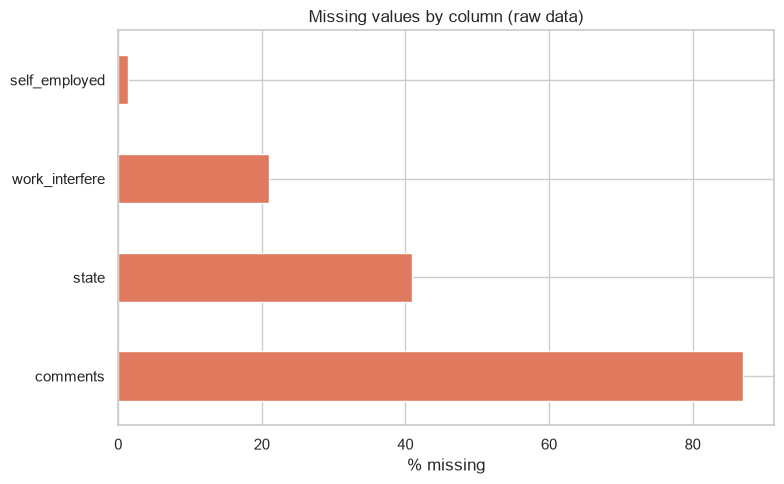

In [9]:
missing = df_raw.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 5))
missing.plot(kind="barh", ax=ax, color="#e07a5f")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column (raw data)")
plt.tight_layout()
plt.show()


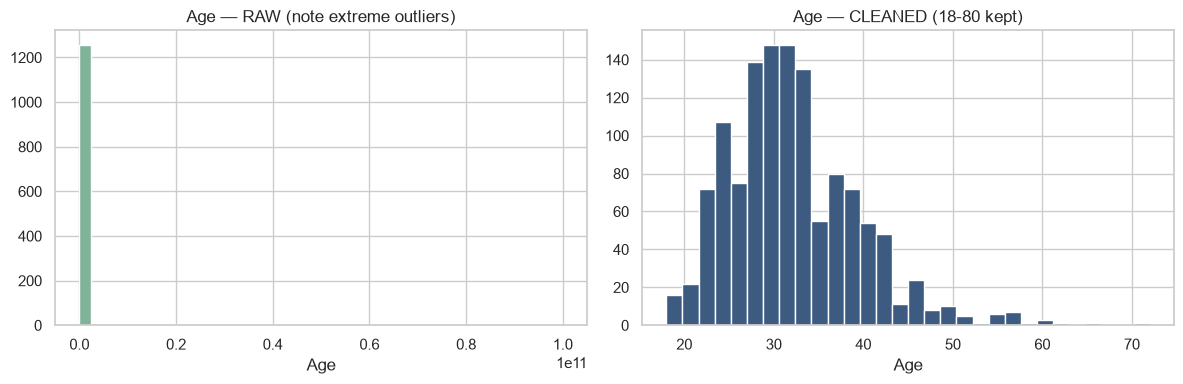

Raw age range: -1726 to 99999999999
Cleaned age range: 18.0 to 72.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw["Age"], bins=40, color="#81b29a")
axes[0].set_title("Age — RAW (note extreme outliers)")
axes[0].set_xlabel("Age")

axes[1].hist(df["Age"].dropna(), bins=30, color="#3d5a80")
axes[1].set_title("Age — CLEANED (18-80 kept)")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

print("Raw age range:", df_raw['Age'].min(), "to", df_raw['Age'].max())
print("Cleaned age range:", df['Age'].min(), "to", df['Age'].max())


In [11]:
print("Raw gender categories:", df_raw['Gender'].nunique())
print("Cleaned gender categories:", df['Gender_clean'].nunique())
df['Gender_clean'].value_counts()


Raw gender categories: 49
Cleaned gender categories: 3


Gender_clean
Male                990
Female              247
Other/Non-binary     21
Name: count, dtype: int64

## 3. Demographics

C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1691410604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Gender_clean", data=df, order=order, ax=axes[1], palette="Set2")
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1691410604.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="self_employed", data=df, ax=axes[2], palette="Set2")


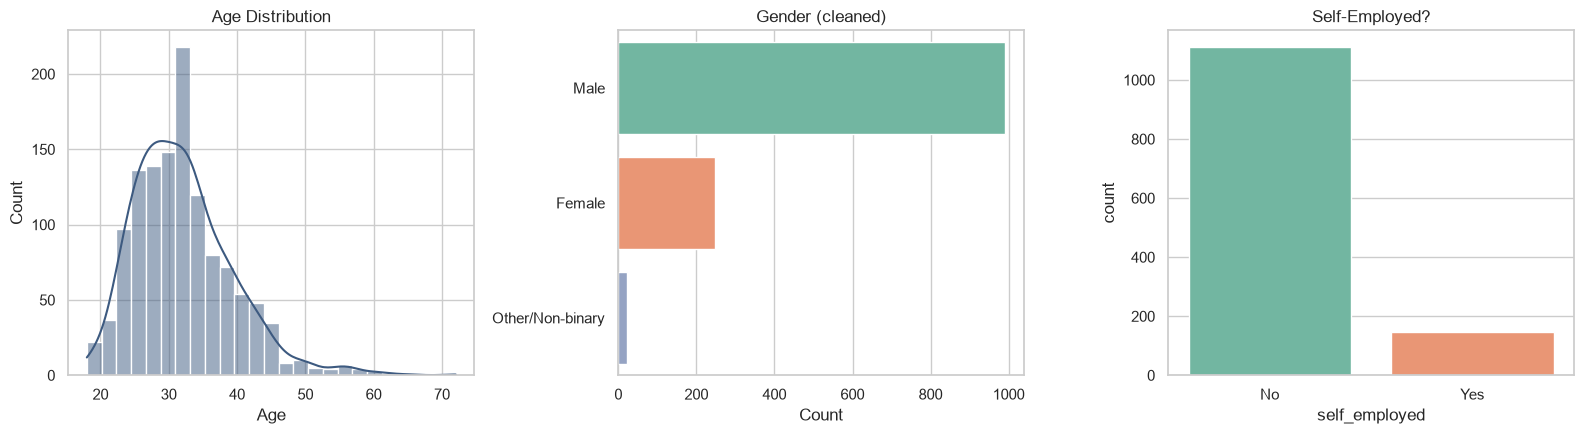

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df["Age"].dropna(), bins=25, kde=True, ax=axes[0], color="#3d5a80")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

order = df["Gender_clean"].value_counts().index
sns.countplot(y="Gender_clean", data=df, order=order, ax=axes[1], palette="Set2")
axes[1].set_title("Gender (cleaned)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

sns.countplot(x="self_employed", data=df, ax=axes[2], palette="Set2")
axes[2].set_title("Self-Employed?")

plt.tight_layout()
plt.show()


C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1404062116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette="crest")


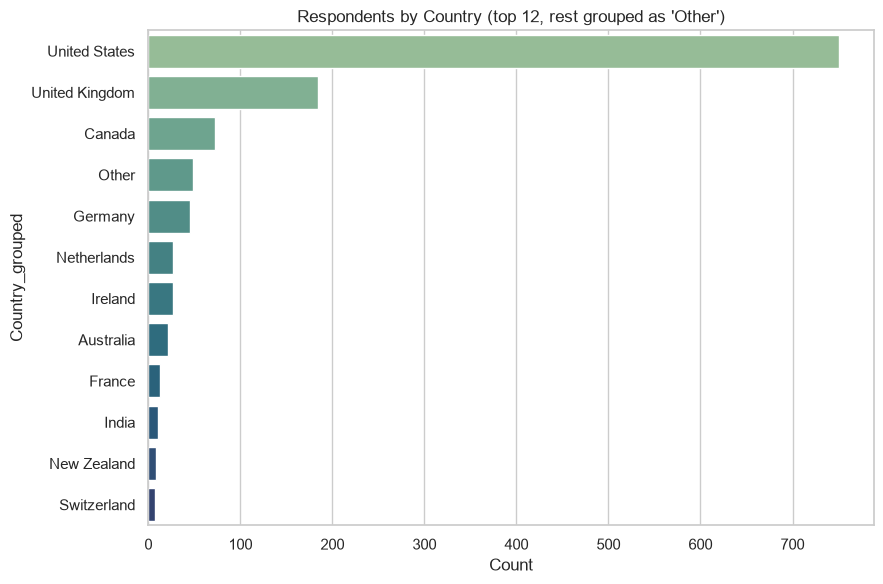

In [13]:
top_countries = df["Country_grouped"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette="crest")
ax.set_title("Respondents by Country (top 12, rest grouped as 'Other')")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\469082322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="company_size", data=df, order=EMPLOYEE_ORDER, ax=ax, palette="flare")


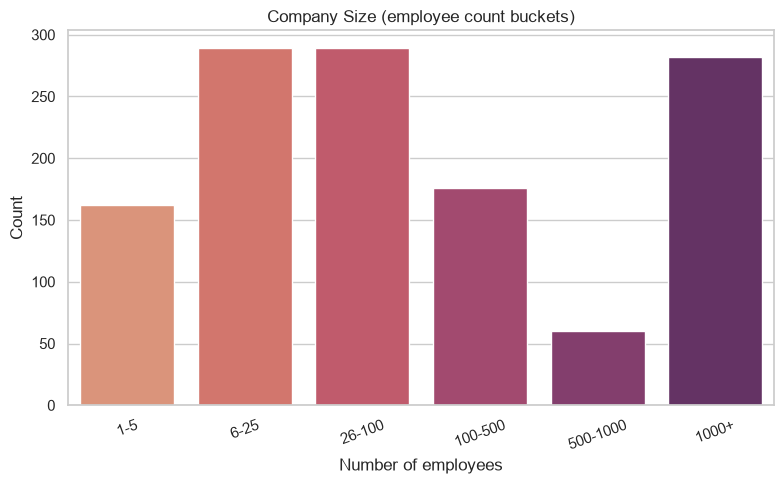

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x="company_size", data=df, order=EMPLOYEE_ORDER, ax=ax, palette="flare")
ax.set_title("Company Size (employee count buckets)")
ax.set_xlabel("Number of employees")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Treatment-seeking behavior

Has the respondent sought treatment for a mental health condition, and what factors relate to it?

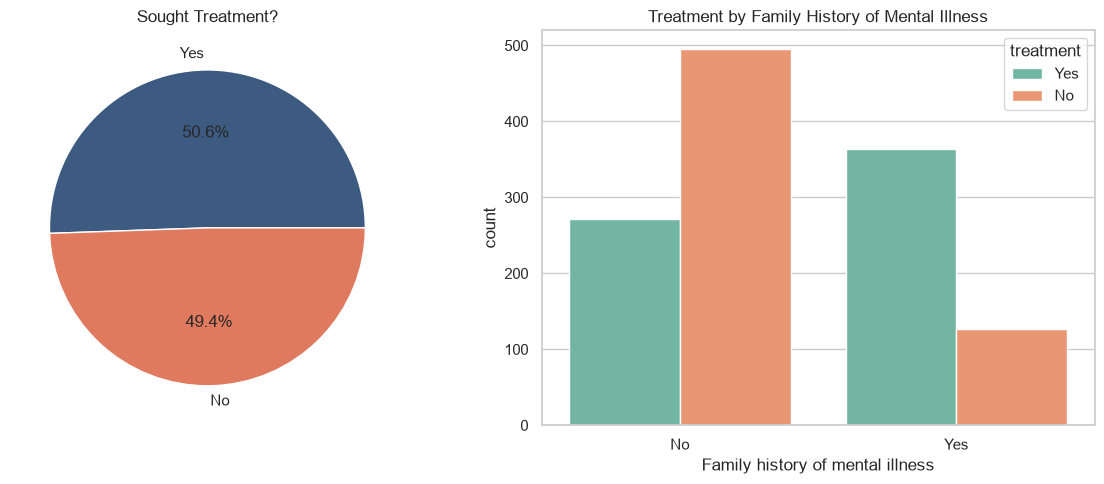

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["treatment"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[0], colors=["#3d5a80", "#e07a5f"], ylabel=""
)
axes[0].set_title("Sought Treatment?")

sns.countplot(x="family_history", hue="treatment", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Treatment by Family History of Mental Illness")
axes[1].set_xlabel("Family history of mental illness")

plt.tight_layout()
plt.show()


C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\757289288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="treatment", y="Age", data=df, ax=ax, palette="Set2")


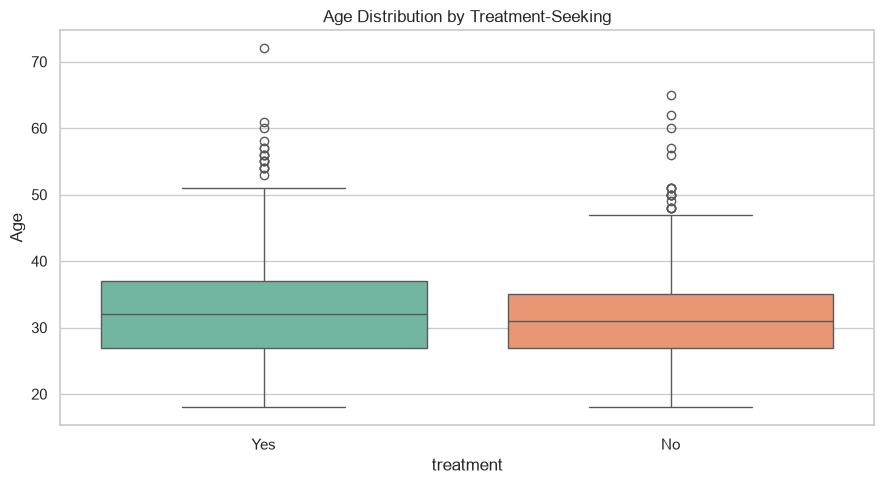

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x="treatment", y="Age", data=df, ax=ax, palette="Set2")
ax.set_title("Age Distribution by Treatment-Seeking")
plt.tight_layout()
plt.show()


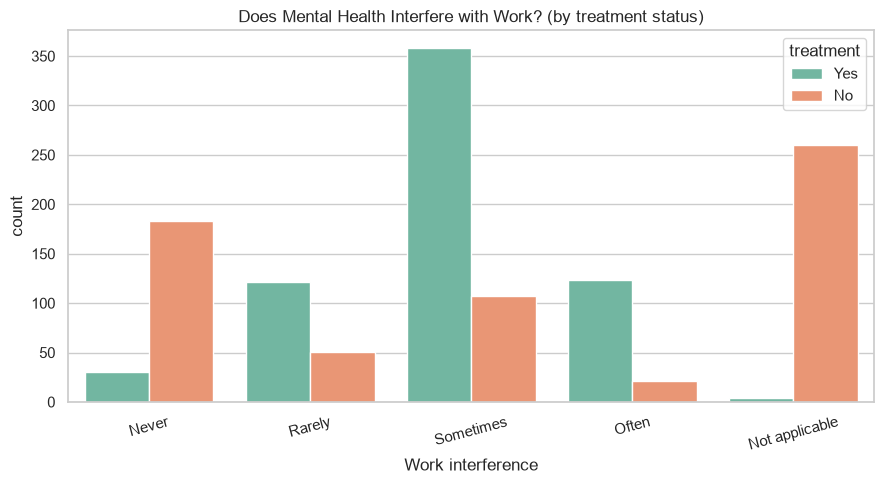

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
order = WORK_INTERFERE_ORDER + ["Not applicable"]
sns.countplot(x="work_interfere", hue="treatment", data=df, order=order, ax=ax, palette="Set2")
ax.set_title("Does Mental Health Interfere with Work? (by treatment status)")
ax.set_xlabel("Work interference")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


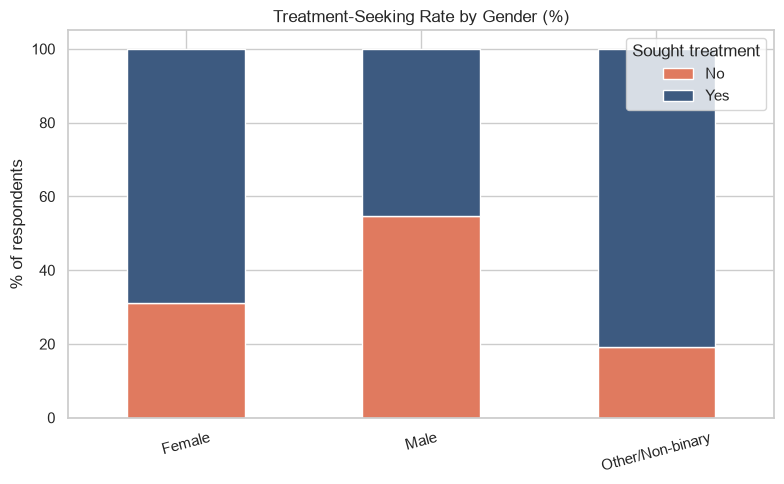

In [18]:
treat_by_gender = pd.crosstab(df["Gender_clean"], df["treatment"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 5))
treat_by_gender.plot(kind="bar", stacked=True, ax=ax, color=["#e07a5f", "#3d5a80"])
ax.set_title("Treatment-Seeking Rate by Gender (%)")
ax.set_ylabel("% of respondents")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.legend(title="Sought treatment")
plt.tight_layout()
plt.show()


## 5. Workplace support & policy

How do company benefits, wellness programs, and openness relate to treatment-seeking and comfort discussing mental health?

C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1923934336.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1923934336.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1923934336.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1923934336.p

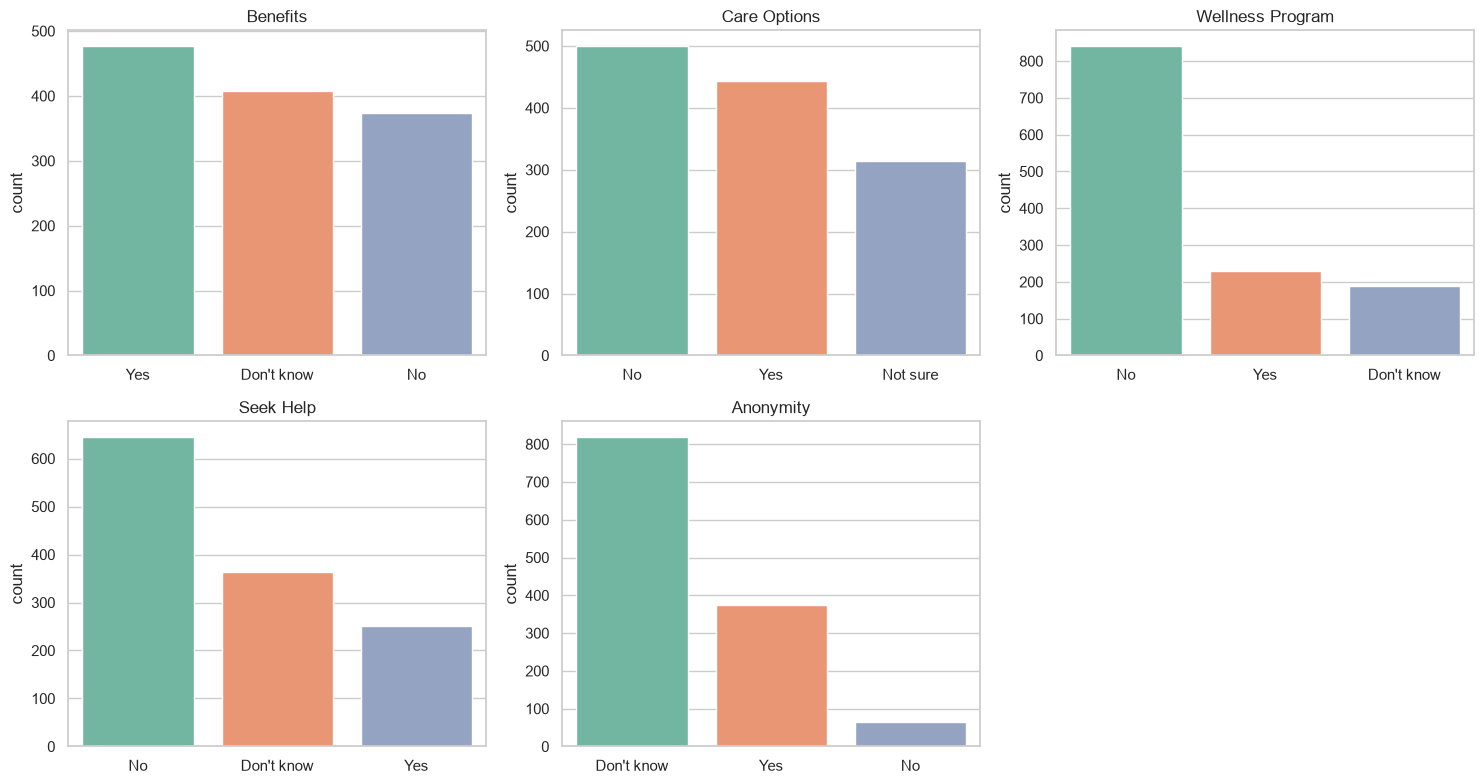

In [19]:
support_cols = ["benefits", "care_options", "wellness_program", "seek_help", "anonymity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(support_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
                  order=df[col].value_counts().index)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\2052217548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="leave", data=df, order=LEAVE_ORDER, ax=ax, palette="flare")


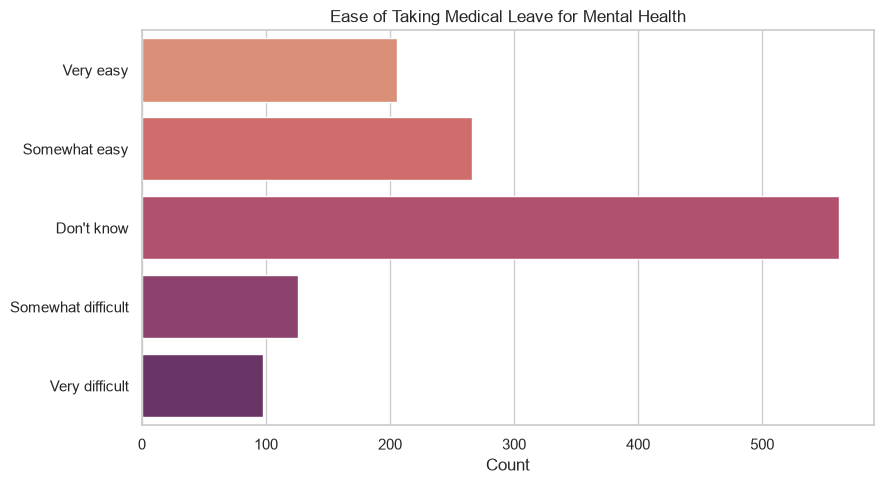

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(y="leave", data=df, order=LEAVE_ORDER, ax=ax, palette="flare")
ax.set_title("Ease of Taking Medical Leave for Mental Health")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\2655182657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\2655182657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\2655182657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\2655182657.p

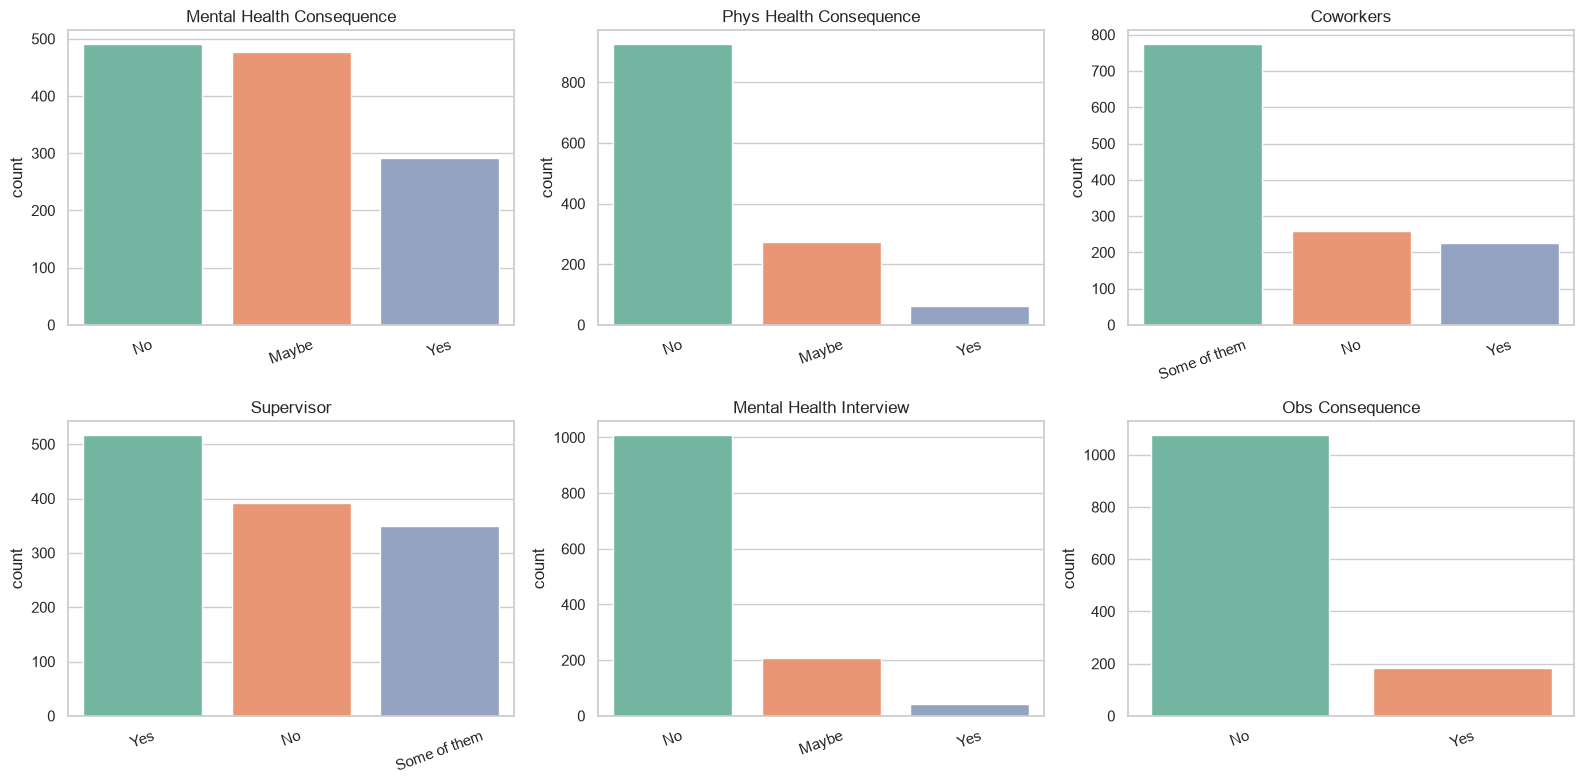

In [21]:
consequence_cols = ["mental_health_consequence", "phys_health_consequence",
                    "coworkers", "supervisor", "mental_health_interview", "obs_consequence"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(consequence_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette="Set2",
                  order=df[col].value_counts().index)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 6. Bivariate & correlation analysis

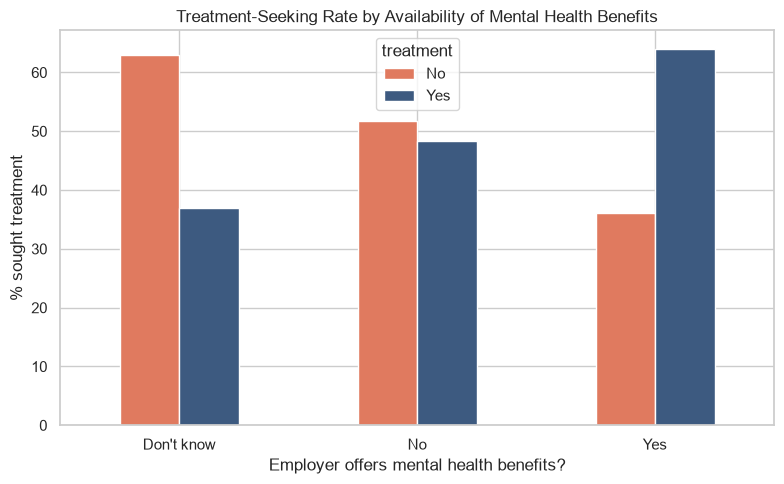

In [22]:
benefits_treatment = pd.crosstab(df["benefits"], df["treatment"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 5))
benefits_treatment.plot(kind="bar", ax=ax, color=["#e07a5f", "#3d5a80"])
ax.set_title("Treatment-Seeking Rate by Availability of Mental Health Benefits")
ax.set_ylabel("% sought treatment")
ax.set_xlabel("Employer offers mental health benefits?")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


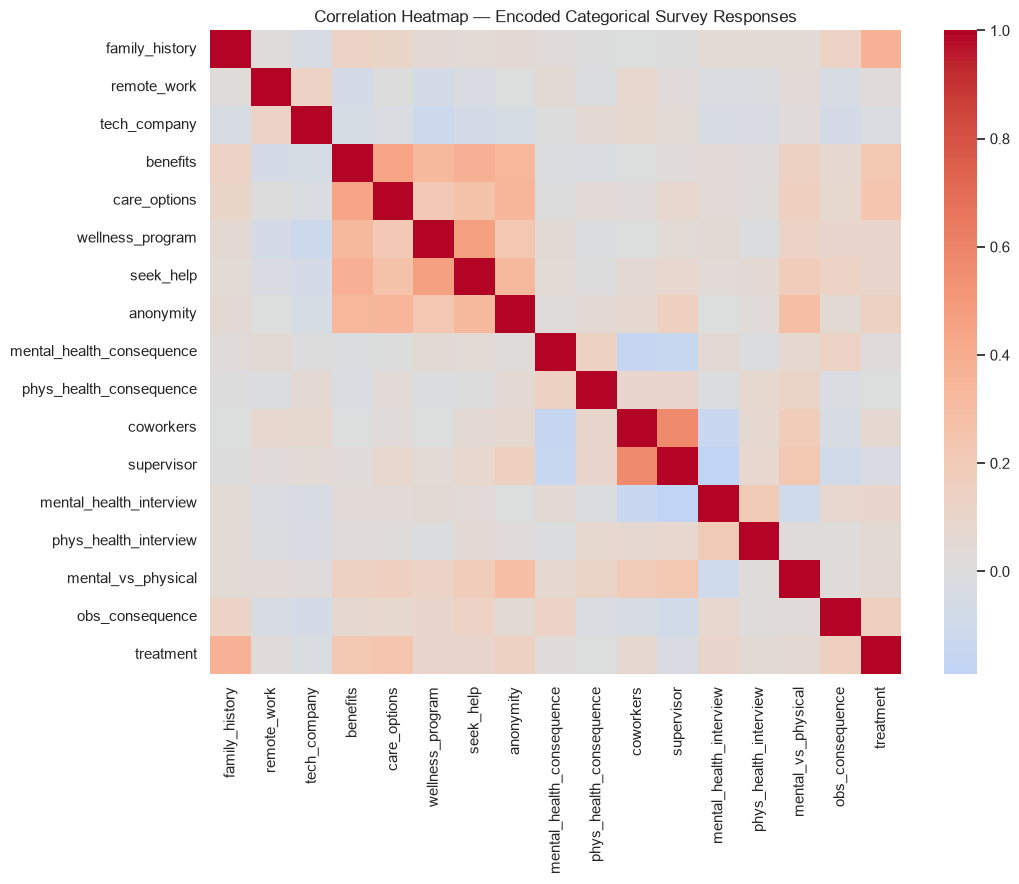

In [23]:
yn_cols = get_yes_no_columns()
encoded = df[yn_cols + ["treatment"]].copy()
for c in encoded.columns:
    encoded[c] = encoded[c].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(encoded.corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation Heatmap — Encoded Categorical Survey Responses")
plt.tight_layout()
plt.show()


C:\Users\Aravind\AppData\Local\Temp\ipykernel_36116\1460946495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="company_size", y="Age", data=df, order=EMPLOYEE_ORDER, ax=ax, palette="crest")


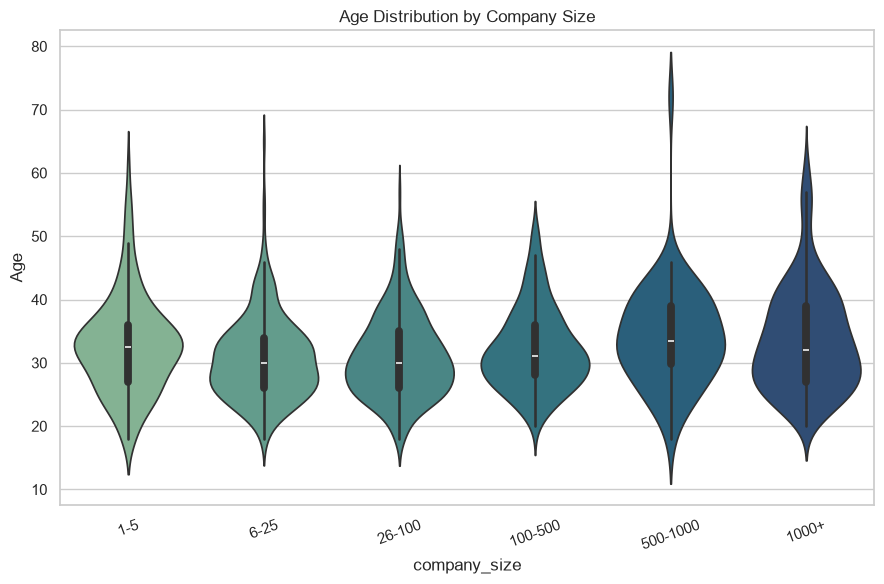

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(x="company_size", y="Age", data=df, order=EMPLOYEE_ORDER, ax=ax, palette="crest")
ax.set_title("Age Distribution by Company Size")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


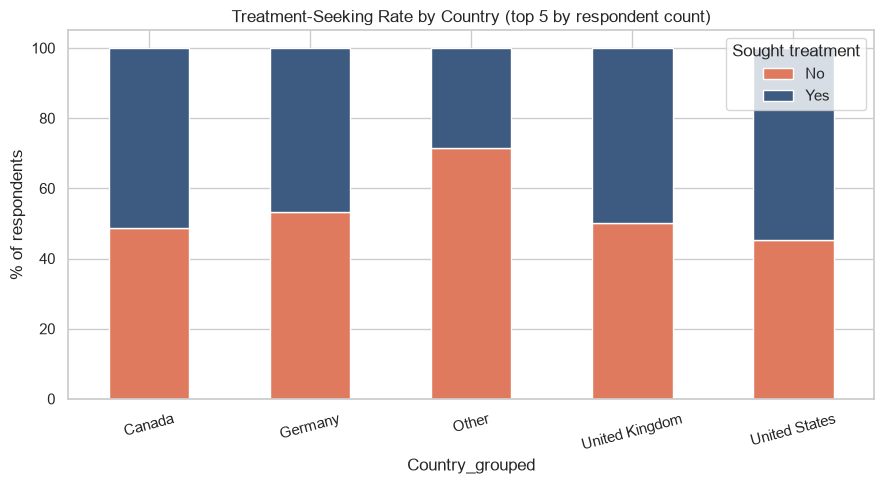

In [25]:
top5 = df["Country_grouped"].value_counts().head(5).index
subset = df[df["Country_grouped"].isin(top5)]
country_treat = pd.crosstab(subset["Country_grouped"], subset["treatment"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
country_treat.plot(kind="bar", stacked=True, ax=ax, color=["#e07a5f", "#3d5a80"])
ax.set_title("Treatment-Seeking Rate by Country (top 5 by respondent count)")
ax.set_ylabel("% of respondents")
plt.xticks(rotation=15)
plt.legend(title="Sought treatment")
plt.tight_layout()
plt.show()


## 7. Key takeaways

Fill in / adjust these based on what the charts above show for your run — a few patterns to look for:

- **Treatment-seeking**: is it associated with family history of mental illness?
- **Work interference**: do people who report treatment also report more work interference (plausibly because treatment-seekers are more aware of/attentive to their symptoms)?
- **Company size & benefits**: does availability of mental health benefits correlate with employees feeling safer to discuss it with supervisors/coworkers?
- **Leave difficulty**: a large "Don't know" share on `leave` suggests many employees are unaware of their own company's mental health leave policy — itself a finding.
- **Country differences**: treatment-seeking rates vary noticeably across the top respondent countries, which may reflect differing healthcare systems and cultural attitudes rather than differing underlying prevalence.

---



#### What do you suggest the client to achieve Business Objective ?



1. **Prioritise awareness over policy existence.** The single biggest gap isn't whether benefits/care-options exist, it's whether employees *know about them* (37-48% treatment rate when unclear vs. 64-69% when clear). A quarterly reminder campaign, onboarding walkthrough, and manager talking points are low-cost, high-leverage fixes.
2. **Target stigma-reduction messaging at male employees specifically**, and repeat it across all career stages, not just onboarding — the treatment-rate gap (Male 45% vs Female 69%) is large and persistent by age group.
3. **Don't rely on remote-work policy or company size as mental-health levers** — both showed weak relationships with treatment-seeking; funds are better spent on the benefits-clarity and stigma levers above.
4. **Pair any "we take mental health seriously" messaging with concrete confidentiality/anti-retaliation guarantees** — fear of consequences didn't stop private treatment-seeking, but it likely does suppress workplace disclosure, which is where presenteeism and burnout risk actually live.
5. **Use the `work_interfere` + `family_history` + `care_options` signals (highest feature importance) to prioritise pilot programs** — e.g. rolling out a new EAP awareness push first in smaller / newer companies (the 6-25 employee band had the lowest treatment rate among well-represented groups).
6. The baseline Random Forest model (**~82% accuracy, ~0.90 ROC-AUC**) shows these workplace-perception signals are predictive enough to power a lightweight, *aggregated and anonymised* wellness-outreach prioritisation tool — never an individual diagnostic or hiring signal.


# **Conclusion**



This project cleaned and explored the 2014 OSMI Mental Health in Tech survey across 1,258 responses, fixing a duplicated row, a corrupted numeric field, a messy free-text gender field, and skip-logic-driven missingness in `work_interfere`. Following the UBM structure, 22 charts — univariate profiles, bivariate cuts against the `treatment` target, and multivariate country/age/gender views plus a correlation heatmap and pair plot — consistently pointed to the same handful of drivers: **how much a condition interferes with work, family history, and — most actionably for a business — whether the employee actually knows what mental-health support is available to them.** Gender also emerged as a striking and persistent gap (women and non-binary respondents seek treatment at meaningfully higher rates than men across every age band), while remote-work status and company size turned out to be weak levers. A baseline Random Forest classifier reached ~82% accuracy / 0.90 ROC-AUC predicting treatment-seeking from these fields, confirming the signal is real and usable. The practical takeaway for a tech employer is that **communicating and normalising existing benefits will likely move the needle more than adding new ones**, and that any outreach strategy should be paired with genuine confidentiality guarantees so that private care-seeking can eventually translate into safer workplace disclosure too.


